In [1]:
# import the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno 
import openpyxl as px
import os
import joblib

import warnings
warnings.filterwarnings('ignore')

#### Load the dataset

In [4]:
path = "/Users/stevenschepanski/Documents/ANALYSIS/GreenSpaces"

In [5]:
# Read data from the CSV files into data frames
rob = pd.read_excel(path + "/data/RiskBias_graphs_GreenSpace.xlsx")

#### Check the dataset

In [6]:
rob.head()

,Author,Selection bias (Random sequence),Selection bias (Allocation),Reporting bias,Other bias,Performance bias,Detection bias,Attrition bias
0,Detweiler 2015,Unclear,Unclear,High,Unclear,High,High,Low
1,Shin 2012,Unclear,Unclear,High,Unclear,High,Unclear,Unclear
2,Hyvönen 2023,Unclear,Unclear,High,High,High,High,Low
3,Yeon 2022,Low,Low,Unclear,High,High,High,High
4,Watkins-Martin 2022,Low,High,High,High,Low,Low,High


In [7]:
# Extract year from "Author" column
rob['Year'] = rob['Author'].str.extract('(\d{4})').astype(int)

# Sort DataFrame by year
rob = rob.sort_values('Year')

# Drop the "Year" column
rob = rob.drop(columns='Year')

# Display the DataFrame
rob.head()

,Author,Selection bias (Random sequence),Selection bias (Allocation),Reporting bias,Other bias,Performance bias,Detection bias,Attrition bias
10,Taylor & Kuo 2009,Unclear,Unclear,High,High,High,High,Unclear
17,Kam and Siu 2010,Unclear,Unclear,High,Unclear,High,Low,Low
14,Luk 2011,Unclear,Unclear,Unclear,Unclear,High,Unclear,Unclear
1,Shin 2012,Unclear,Unclear,High,Unclear,High,Unclear,Unclear
0,Detweiler 2015,Unclear,Unclear,High,Unclear,High,High,Low


#### Overview table 1

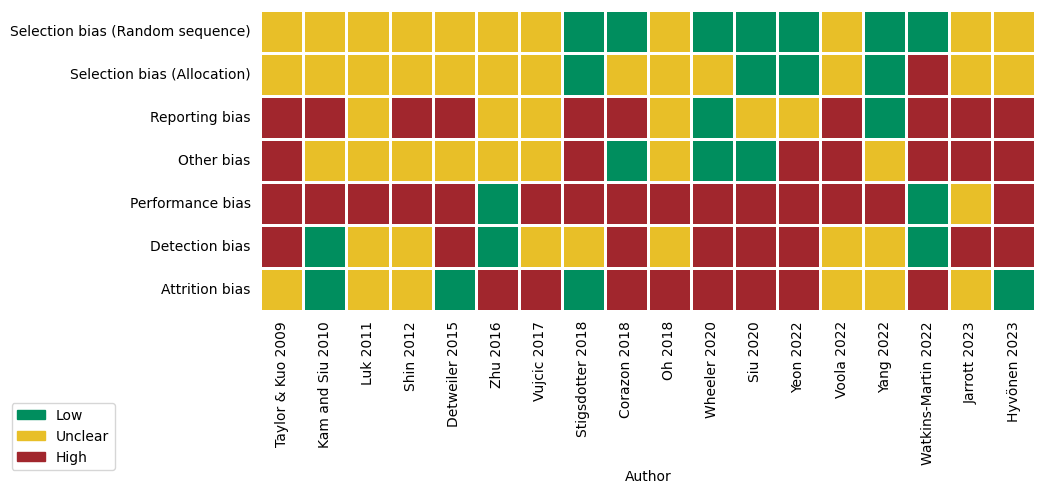

In [15]:
import matplotlib.patches as mpatches

# Strip trailing spaces
rob = rob.applymap(lambda x: x.strip() if isinstance(x, str) else x)

# Replace 'Low', 'High', 'Unclear' with numerical values
rob.replace({'Low': 0, 'High': 2, 'Unclear': 1}, inplace=True)

# Define a custom color map
cmap = {0: '#008e5e', 1: '#e8bf28', 2: '#a1262d'}
cmap = [cmap[i] for i in range(3)]

# Create a heatmap
plt.figure(figsize=(10, 8))
risk = sns.heatmap(rob.set_index('Author').T, cmap=cmap, annot=False, cbar=False, linewidths=1
            , square=True, xticklabels=True, yticklabels=True)

# remove ticks
risk.tick_params(left=False, bottom=False)

# Create legend
low_patch = mpatches.Patch(color='#008e5e', label='Low')
unclear_patch = mpatches.Patch(color='#e8bf28', label='Unclear')
high_patch = mpatches.Patch(color='#a1262d', label='High')

# Add legend to the outside of the plot
plt.legend(handles=[low_patch, unclear_patch, high_patch], loc='lower left', bbox_to_anchor=(-0.33, -0.55))

# Add a diagonal text overlay
# plt.text(0, 1, 'Work in Progress', fontsize=60, color='black', ha='left', va='top', alpha=0.2, rotation=20)

# Show the plot
plt.show()

#### Overview table 2

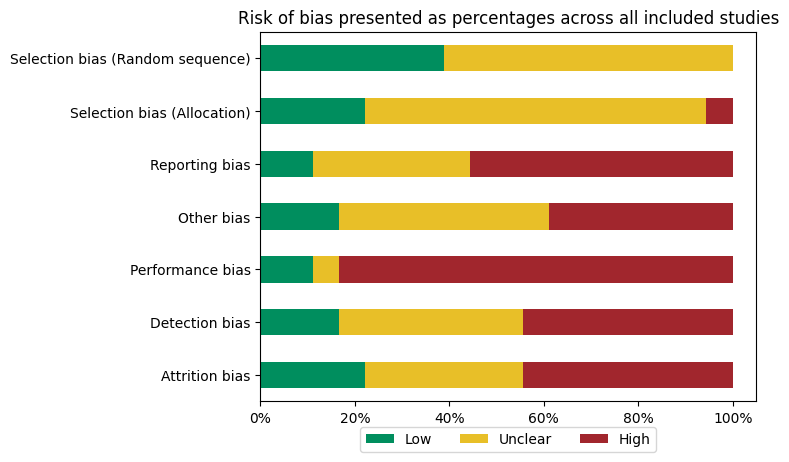

In [16]:
# Calculate the percentages of 'low', 'high', and 'unclear' for each feature
percentages = rob.drop(columns='Author').apply(lambda x: x.value_counts() / len(x))

# Plot a stacked bar chart with reversed y-axis order
percentages.T[::-1].plot(kind='barh', stacked=True, color=['#008e5e', '#e8bf28', '#a1262d'])

# Change the x-axis ticks
plt.xticks([0, 0.2, 0.4, 0.6, 0.8, 1], ['0%', '20%', '40%', '60%', '80%', '100%'])

# Set the title
plt.title('Risk of bias presented as percentages across all included studies')

# Add a legend below the plot
plt.legend(['Low', 'Unclear', 'High'], loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=5)

# Add a diagonal text overlay with a high zorder
# plt.text(0, 1, 'Work in Progress', fontsize=60, color='black', ha='left', va='baseline', alpha=0.2, rotation=20, zorder=5)

# Show the plot
plt.show()
